###Import Libraries

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

###Load Dataset

In [2]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

###Preprocessing

In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

###Build LSTM Model

In [4]:
model = Sequential([
    Embedding(vocab_size, 128),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

###Compile Model

In [5]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

###Train Model

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 281s 704ms/step - accuracy: 0.7400 - loss: 0.5145 - val_accuracy: 0.8004 - val_loss: 0.4421
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 360s 803ms/step - accuracy: 0.8401 - loss: 0.3751 - val_accuracy: 0.8468 - val_loss: 0.3609
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 275s 703ms/step - accuracy: 0.8825 - loss: 0.2942 - val_accuracy: 0.8406 - val_loss: 0.3731
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 278s 711ms/step - accuracy: 0.8987 - loss: 0.2571 - val_accuracy: 0.8608 - val_loss: 0.3585
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 281s 720ms/step - accuracy: 0.9198 - loss: 0.2086 - val_accuracy: 0.8484 - val_loss: 0.3913


###Evaluate Model

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.8484 - loss: 0.3913
Test Accuracy: 0.848360002040863


###Plot Accuracy

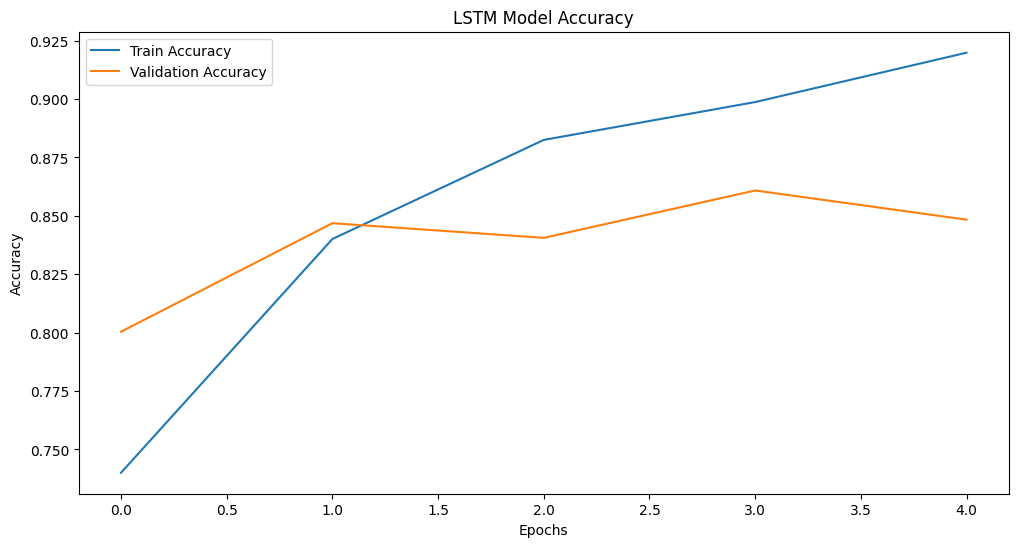

In [8]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

###Plot Loss

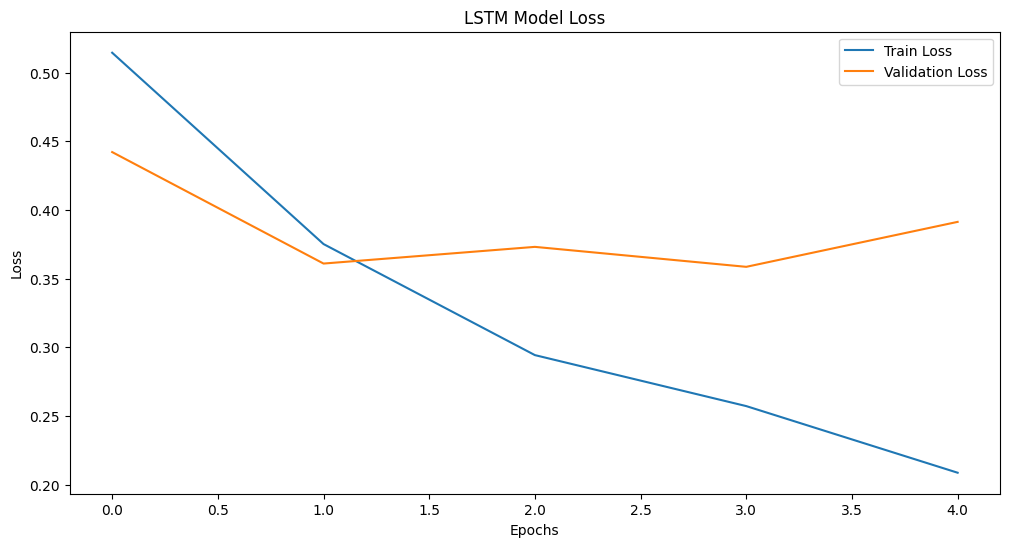

In [9]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()